# XGBoost Taxi Classification

Classifies NYC taxi trips as *yellow* vs *green* in two settings:

- **Part A** – raw trip-level data (trip distance, duration, hour, day-of-week, passenger count)
- **Part B** – pivoted (date × taxi_type × pickup_location × hour) tables; hourly profile → PCA → PC1–PC5

Both parts use **Dask** to load Parquet data and **XGBClassifier** for classification.


## Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import dask
import dask.dataframe as dd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

print(f"dask     {dask.__version__}")
print(f"sklearn  {__import__('sklearn').__version__}")
print(f"xgboost  {__import__('xgboost').__version__}")
print("All imports OK.")


dask     2024.8.0
sklearn  1.6.1
xgboost  2.1.4
All imports OK.


## Configuration

Set all data paths and hyperparameters here.

In [4]:
# ── Raw trip-level S3 paths (anonymous access) ────────────────────────────
RAW_YELLOW_PATH = "s3://dsc291-ucsd/taxi/Dataset/2021/yellow_taxi/yellow_tripdata_2021-01.parquet"
RAW_GREEN_PATH  = "s3://dsc291-ucsd/taxi/Dataset/2021/green_taxi/green_tripdata_2021-01.parquet"
S3_STORAGE_OPTS = {"anon": True}

# ── Pivoted parquet for Part B ─────────────────────────────────────────────
# Set to a local or S3 path to skip inline pivoting; None → build from raw data.
# Example: "../hw1_output/final_table.parquet"
PART_B_PIVOTED_PATH = None

# ── Part A settings ───────────────────────────────────────────────────────
MAX_ROWS_PER_CLASS = 50_000   # rows sampled per class (set None for no cap)
TRAIN_FRAC        = 0.80      # train/validation split fraction
RANDOM_SEED       = 42        # reproducibility seed

FEATURES_A = ["trip_distance", "trip_duration_min", "hour", "day_of_week", "passenger_count"]

# ── Part B settings ───────────────────────────────────────────────────────
PART_B_SAMPLE_FRAC = 0.15     # fraction of each raw file sampled before pivoting
MIN_RIDES          = 20       # min total rides per (date, pickup_place) cell
N_PCA_COMPONENTS   = 5        # number of PCA components → features for Part B

HOUR_COLS = [f"hour_{h}" for h in range(24)]

print("Config loaded.")
print(f"  MAX_ROWS_PER_CLASS = {MAX_ROWS_PER_CLASS:,}")
print(f"  TRAIN_FRAC         = {TRAIN_FRAC}")
print(f"  RANDOM_SEED        = {RANDOM_SEED}")
print(f"  PART_B_SAMPLE_FRAC = {PART_B_SAMPLE_FRAC}")
print(f"  N_PCA_COMPONENTS   = {N_PCA_COMPONENTS}")


Config loaded.
  MAX_ROWS_PER_CLASS = 50,000
  TRAIN_FRAC         = 0.8
  RANDOM_SEED        = 42
  PART_B_SAMPLE_FRAC = 0.15
  N_PCA_COMPONENTS   = 5


---
## Part A: Classification from Raw Trip Data

### A-1. Load and Prepare

Load one month of yellow and green trip-level Parquet files from S3 using Dask.
Column names differ between taxi types (`tpep_*` for yellow, `lpep_*` for green);
we normalise to a common schema before combining.


In [5]:
# ── Column normalisation helpers ──────────────────────────────────────────

_PICKUP_VARIANTS  = [
    "tpep_pickup_datetime", "lpep_pickup_datetime",
    "pickup_datetime", "Trip_Pickup_DateTime", "pickup_date",
]
_DROPOFF_VARIANTS = [
    "tpep_dropoff_datetime", "lpep_dropoff_datetime",
    "dropoff_datetime", "Trip_Dropoff_DateTime", "dropoff_date",
]


def _first_match(col_list, candidates):
    col_set = set(col_list)
    for c in candidates:
        if c in col_set:
            return c
    return None


def normalize_trip_ddf(ddf, taxi_type_int: int):
    """
    Rename taxi-type-specific pickup/dropoff columns to unified names and
    add a numeric taxi_type label column.  Returns a new Dask DataFrame.
    """
    cols = ddf.columns.tolist()
    rename = {}
    pu = _first_match(cols, _PICKUP_VARIANTS)
    do = _first_match(cols, _DROPOFF_VARIANTS)
    if pu:
        rename[pu] = "raw_pickup_datetime"
    if do:
        rename[do] = "raw_dropoff_datetime"
    if rename:
        ddf = ddf.rename(columns=rename)
    ddf["taxi_type_int"] = taxi_type_int
    return ddf


# ── Load with Dask ────────────────────────────────────────────────────────
print("Loading yellow taxi data with Dask …")
yellow_ddf = dd.read_parquet(RAW_YELLOW_PATH, storage_options=S3_STORAGE_OPTS)
yellow_ddf = normalize_trip_ddf(yellow_ddf, taxi_type_int=0)

print("Loading green  taxi data with Dask …")
green_ddf = dd.read_parquet(RAW_GREEN_PATH, storage_options=S3_STORAGE_OPTS)
green_ddf = normalize_trip_ddf(green_ddf, taxi_type_int=1)

print(f"Yellow  partitions: {yellow_ddf.npartitions}")
print(f"Green   partitions: {green_ddf.npartitions}")
print("Dask DataFrames ready (lazy).")


Loading yellow taxi data with Dask …
Loading green  taxi data with Dask …
Yellow  partitions: 1
Green   partitions: 1
Dask DataFrames ready (lazy).


In [6]:
# ── Sample per class and compute to pandas ────────────────────────────────

def sample_and_compute(ddf, max_rows, seed):
    """Sample up to max_rows rows from a Dask DataFrame, compute to pandas."""
    if max_rows is None:
        return ddf.compute()
    n_total = len(ddf)                          # fast: reads parquet row-group metadata
    frac    = min(1.0, (max_rows * 1.15) / n_total)
    pdf     = ddf.sample(frac=frac, random_state=seed).compute()
    if len(pdf) > max_rows:
        pdf = pdf.sample(n=max_rows, random_state=seed)
    return pdf.reset_index(drop=True)


print(f"Sampling up to {MAX_ROWS_PER_CLASS:,} rows per class …")
yellow_pd = sample_and_compute(yellow_ddf, MAX_ROWS_PER_CLASS, RANDOM_SEED)
green_pd  = sample_and_compute(green_ddf,  MAX_ROWS_PER_CLASS, RANDOM_SEED)

print(f"  Yellow sampled rows: {len(yellow_pd):,}")
print(f"  Green  sampled rows: {len(green_pd):,}")


Sampling up to 50,000 rows per class …
  Yellow sampled rows: 50,000
  Green  sampled rows: 50,000


In [7]:
# ── Feature engineering and cleaning ─────────────────────────────────────

def engineer_features(pdf: pd.DataFrame) -> pd.DataFrame:
    """
    Derive trip_duration_min, hour, day_of_week; cast numeric columns;
    drop rows with missing or non-positive values for key features.
    """
    pdf = pdf.copy()
    pdf["pickup_dt"]  = pd.to_datetime(pdf["raw_pickup_datetime"],  errors="coerce")
    pdf["dropoff_dt"] = pd.to_datetime(pdf.get("raw_dropoff_datetime", pd.NaT),
                                       errors="coerce")

    pdf["trip_duration_min"] = (
        (pdf["dropoff_dt"] - pdf["pickup_dt"]).dt.total_seconds() / 60.0
    )
    pdf["hour"]        = pdf["pickup_dt"].dt.hour
    pdf["day_of_week"] = pdf["pickup_dt"].dt.dayofweek   # 0=Mon … 6=Sun

    for col in ["trip_distance", "passenger_count"]:
        if col in pdf.columns:
            pdf[col] = pd.to_numeric(pdf[col], errors="coerce")

    required = ["trip_distance", "trip_duration_min", "passenger_count",
                "hour", "day_of_week"]
    pdf = pdf.dropna(subset=required)
    pdf = pdf[pdf["trip_distance"]    > 0]
    pdf = pdf[pdf["trip_duration_min"]> 0]
    pdf = pdf[pdf["passenger_count"]  > 0]
    return pdf.reset_index(drop=True)


yellow_clean = engineer_features(yellow_pd)
green_clean  = engineer_features(green_pd)

all_trips = pd.concat([yellow_clean, green_clean], ignore_index=True)

X_a = all_trips[FEATURES_A].values.astype(float)
y_a = all_trips["taxi_type_int"].values.astype(int)

print(f"Clean dataset: {len(all_trips):,} rows")
print(f"  Yellow (0): {(y_a == 0).sum():,}")
print(f"  Green  (1): {(y_a == 1).sum():,}")


Clean dataset: 69,877 rows
  Yellow (0): 44,801
  Green  (1): 25,076


### A-3. Train and Evaluate

Stratified 80/20 train-validation split; multi-class `XGBClassifier` with
`objective="multi:softmax"`.


In [8]:
X_a_train, X_a_val, y_a_train, y_a_val = train_test_split(
    X_a, y_a,
    train_size=TRAIN_FRAC,
    stratify=y_a,
    random_state=RANDOM_SEED,
)

n_classes_a = int(y_a.max()) + 1

clf_a = XGBClassifier(
    objective     = "multi:softmax",
    num_class     = n_classes_a,
    n_estimators  = 100,
    max_depth     = 4,
    learning_rate = 0.1,
    subsample     = 0.8,
    random_state  = RANDOM_SEED,
    eval_metric   = "mlogloss",
    verbosity     = 0,
)

print(f"Fitting XGBClassifier (n_classes={n_classes_a}, n_estimators=100) …")
clf_a.fit(X_a_train, y_a_train)

y_a_pred = clf_a.predict(X_a_val)
acc_a    = accuracy_score(y_a_val, y_a_pred)

print(f"\nPart A Validation Accuracy: {acc_a:.4f}")
print("\nClassification Report:")
print(classification_report(y_a_val, y_a_pred, target_names=["yellow", "green"]))


Fitting XGBClassifier (n_classes=2, n_estimators=100) …

Part A Validation Accuracy: 0.6670

Classification Report:
              precision    recall  f1-score   support

      yellow       0.67      0.93      0.78      8961
       green       0.61      0.20      0.30      5015

    accuracy                           0.67     13976
   macro avg       0.64      0.56      0.54     13976
weighted avg       0.65      0.67      0.61     13976



### A-4. Interpret

Three panels: (1) confusion matrix, (2) feature importance, (3) feature value range for yellow trips.

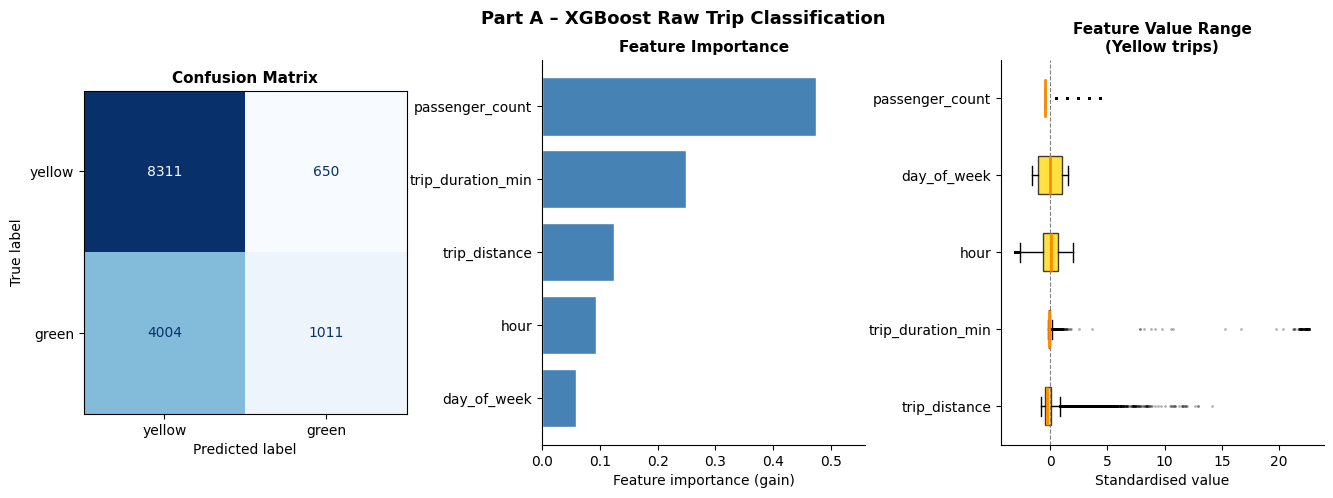

Saved: part_a_interpretation.png


In [9]:
fig_a = plt.figure(figsize=(16, 5))
gs_a  = gridspec.GridSpec(1, 3, figure=fig_a, wspace=0.42)

# ── Panel 1: Confusion Matrix ─────────────────────────────────────────────
ax_a1 = fig_a.add_subplot(gs_a[0])
cm_a  = confusion_matrix(y_a_val, y_a_pred)
disp_a = ConfusionMatrixDisplay(confusion_matrix=cm_a,
                                 display_labels=["yellow", "green"])
disp_a.plot(ax=ax_a1, colorbar=False, cmap="Blues")
ax_a1.set_title("Confusion Matrix", fontsize=11, fontweight="bold")

# ── Panel 2: Feature Importance ───────────────────────────────────────────
ax_a2 = fig_a.add_subplot(gs_a[1])
imp_a      = clf_a.feature_importances_
sorted_idx = np.argsort(imp_a)
ax_a2.barh([FEATURES_A[i] for i in sorted_idx], imp_a[sorted_idx],
            color="steelblue", edgecolor="white")
ax_a2.set_xlabel("Feature importance (gain)")
ax_a2.set_title("Feature Importance", fontsize=11, fontweight="bold")
ax_a2.set_xlim(0, imp_a.max() * 1.18)
for spine in ["top", "right"]:
    ax_a2.spines[spine].set_visible(False)

# ── Panel 3: Feature value range for yellow trips (normalised boxplot) ────
ax_a3  = fig_a.add_subplot(gs_a[2])
yellow_vals = all_trips.loc[all_trips["taxi_type_int"] == 0, FEATURES_A]
yellow_norm = (yellow_vals - yellow_vals.mean()) / yellow_vals.std()
ax_a3.boxplot(
    [yellow_norm[c].dropna().values for c in FEATURES_A],
    labels=FEATURES_A,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="gold", alpha=0.75),
    medianprops=dict(color="darkorange", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
ax_a3.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax_a3.set_xlabel("Standardised value")
ax_a3.set_title("Feature Value Range\n(Yellow trips)", fontsize=11, fontweight="bold")
for spine in ["top", "right"]:
    ax_a3.spines[spine].set_visible(False)

fig_a.suptitle("Part A – XGBoost Raw Trip Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part_a_interpretation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: part_a_interpretation.png")


---
## Part B: Classification from Pivoted Tables

### B-1. Load Pivoted Table

If `PART_B_PIVOTED_PATH` is set, load the pre-built wide table with Dask.
Otherwise, sample each raw Dask DataFrame, aggregate trip counts by
`(taxi_type, date, pickup_place, hour)`, and pivot to a 24-column wide table.
Rows with fewer than `MIN_RIDES` total trips are discarded.


In [10]:
def build_pivot_for_type(ddf, taxi_type_label: str,
                         sample_frac: float, seed: int) -> pd.DataFrame:
    """
    Sample a raw trip Dask DataFrame, compute to pandas, build an hourly
    pivot table indexed by (taxi_type, date, pickup_place).
    """
    pdf = ddf.sample(frac=sample_frac, random_state=seed).compute()

    # Parse pickup datetime
    pu_col = "raw_pickup_datetime"
    pdf["pickup_dt"]    = pd.to_datetime(pdf[pu_col], errors="coerce")
    pdf["date"]         = pdf["pickup_dt"].dt.date.astype(str)
    pdf["hour"]         = pdf["pickup_dt"].dt.hour
    pdf["pickup_place"] = pdf["PULocationID"].astype(str)
    pdf["taxi_type"]    = taxi_type_label

    pdf = pdf.dropna(subset=["date", "hour", "pickup_place"])
    pdf = pdf[pdf["hour"].between(0, 23)]

    counts = (
        pdf
        .groupby(["taxi_type", "date", "pickup_place", "hour"])
        .size()
        .reset_index(name="n")
    )
    pivot = counts.pivot_table(
        index   = ["taxi_type", "date", "pickup_place"],
        columns = "hour",
        values  = "n",
        fill_value = 0,
    )
    pivot.columns = [f"hour_{int(h)}" for h in pivot.columns]
    # Ensure all 24 hour columns exist
    for h in range(24):
        if f"hour_{h}" not in pivot.columns:
            pivot[f"hour_{h}"] = 0
    return pivot[HOUR_COLS].reset_index()


# ── Load or build the pivot table ────────────────────────────────────────
if PART_B_PIVOTED_PATH is not None:
    print(f"Loading pre-built pivoted parquet from: {PART_B_PIVOTED_PATH}")
    _sopts = S3_STORAGE_OPTS if str(PART_B_PIVOTED_PATH).startswith("s3://") else {}
    pivot_b_raw = dd.read_parquet(PART_B_PIVOTED_PATH, storage_options=_sopts).compute()
    if "taxi_type" not in pivot_b_raw.columns:
        pivot_b_raw = pivot_b_raw.reset_index()
    pivot_b = pivot_b_raw[pivot_b_raw["taxi_type"].isin(["yellow", "green"])].copy()
else:
    print("Building pivoted table from raw S3 data with Dask …")
    print(f"  Sampling {PART_B_SAMPLE_FRAC:.0%} of each file …")

    print("  Processing yellow (via Dask) …")
    yellow_pivot = build_pivot_for_type(
        yellow_ddf, "yellow", PART_B_SAMPLE_FRAC, RANDOM_SEED
    )
    print(f"    Yellow pivot rows: {len(yellow_pivot):,}")

    print("  Processing green (via Dask) …")
    green_pivot = build_pivot_for_type(
        green_ddf, "green", PART_B_SAMPLE_FRAC, RANDOM_SEED
    )
    print(f"    Green  pivot rows: {len(green_pivot):,}")

    pivot_b = pd.concat([yellow_pivot, green_pivot], ignore_index=True)

# ── Filter low-count cells ────────────────────────────────────────────────
total_rides = pivot_b[HOUR_COLS].sum(axis=1)
n_before    = len(pivot_b)
pivot_b     = pivot_b[total_rides >= MIN_RIDES].reset_index(drop=True)

print(f"\nPivot table after MIN_RIDES={MIN_RIDES} filter:")
print(f"  Rows before filter : {n_before:,}")
print(f"  Rows after  filter : {len(pivot_b):,}")
print(f"  Yellow: {(pivot_b['taxi_type'] == 'yellow').sum():,}")
print(f"  Green : {(pivot_b['taxi_type'] == 'green').sum():,}")


Building pivoted table from raw S3 data with Dask …
  Sampling 15% of each file …
  Processing yellow (via Dask) …
    Yellow pivot rows: 5,586
  Processing green (via Dask) …
    Green  pivot rows: 3,383

Pivot table after MIN_RIDES=20 filter:
  Rows before filter : 8,969
  Rows after  filter : 1,664
  Yellow: 1,590
  Green : 74


### B-2. Features – Hourly Proportions → PCA

Convert raw hourly counts to row proportions (each row sums to 1),
then reduce the 24-dimensional profile to `N_PCA_COMPONENTS` principal components.


In [11]:
# ── Hourly proportions ────────────────────────────────────────────────────
hour_counts = pivot_b[HOUR_COLS].values.astype(float)
row_totals  = hour_counts.sum(axis=1, keepdims=True)
row_totals  = np.where(row_totals == 0, 1.0, row_totals)   # guard against empty rows
hour_props  = hour_counts / row_totals

# ── PCA ───────────────────────────────────────────────────────────────────
pca     = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
pc_mat  = pca.fit_transform(hour_props)

PC_NAMES = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)]
df_b = pd.DataFrame(pc_mat, columns=PC_NAMES)
df_b["taxi_type"] = pivot_b["taxi_type"].values

print("Explained variance ratio per PC:")
for name, var in zip(PC_NAMES, pca.explained_variance_ratio_):
    print(f"  {name}: {var:.4f}")
print(f"Cumulative ({N_PCA_COMPONENTS} PCs): {pca.explained_variance_ratio_.sum():.4f}")


Explained variance ratio per PC:
  PC1: 0.1477
  PC2: 0.1018
  PC3: 0.0811
  PC4: 0.0722
  PC5: 0.0681
Cumulative (5 PCs): 0.4710


### B-3. Train and Evaluate

In [12]:
le_b    = LabelEncoder()
y_b     = le_b.fit_transform(df_b["taxi_type"])
X_b     = df_b[PC_NAMES].values.astype(float)

print(f"Label mapping: { {k: int(v) for k, v in zip(le_b.classes_, le_b.transform(le_b.classes_))} }")

X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_b, y_b,
    train_size = TRAIN_FRAC,
    stratify   = y_b,
    random_state = RANDOM_SEED,
)

n_classes_b = len(le_b.classes_)
clf_b = XGBClassifier(
    objective     = "multi:softmax",
    num_class     = n_classes_b,
    n_estimators  = 100,
    max_depth     = 4,
    learning_rate = 0.1,
    subsample     = 0.8,
    random_state  = RANDOM_SEED,
    eval_metric   = "mlogloss",
    verbosity     = 0,
)

print(f"\nFitting XGBClassifier (n_classes={n_classes_b}, n_estimators=100) …")
clf_b.fit(X_b_train, y_b_train)

y_b_pred = clf_b.predict(X_b_val)
acc_b    = accuracy_score(y_b_val, y_b_pred)

print(f"\nPart B Validation Accuracy: {acc_b:.4f}")
print("\nClassification Report:")
print(classification_report(y_b_val, y_b_pred, target_names=le_b.classes_))


Label mapping: {'green': 0, 'yellow': 1}

Fitting XGBClassifier (n_classes=2, n_estimators=100) …

Part B Validation Accuracy: 0.9580

Classification Report:
              precision    recall  f1-score   support

       green       1.00      0.07      0.12        15
      yellow       0.96      1.00      0.98       318

    accuracy                           0.96       333
   macro avg       0.98      0.53      0.55       333
weighted avg       0.96      0.96      0.94       333



### B-4. Interpret

Confusion matrix and PC feature importance.

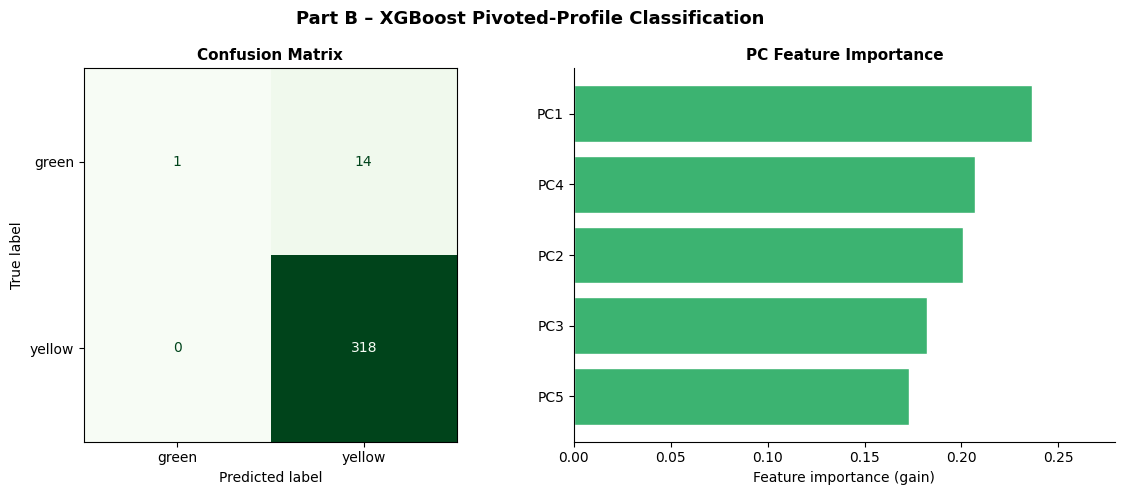

Saved: part_b_interpretation.png


In [13]:
fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel 1: Confusion Matrix ─────────────────────────────────────────────
cm_b   = confusion_matrix(y_b_val, y_b_pred)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b,
                                 display_labels=le_b.classes_)
disp_b.plot(ax=ax_b1, colorbar=False, cmap="Greens")
ax_b1.set_title("Confusion Matrix", fontsize=11, fontweight="bold")

# ── Panel 2: PC Feature Importance ───────────────────────────────────────
imp_b    = clf_b.feature_importances_
sorted_b = np.argsort(imp_b)
ax_b2.barh([PC_NAMES[i] for i in sorted_b], imp_b[sorted_b],
            color="mediumseagreen", edgecolor="white")
ax_b2.set_xlabel("Feature importance (gain)")
ax_b2.set_title("PC Feature Importance", fontsize=11, fontweight="bold")
ax_b2.set_xlim(0, imp_b.max() * 1.18)
for spine in ["top", "right"]:
    ax_b2.spines[spine].set_visible(False)

fig_b.suptitle("Part B – XGBoost Pivoted-Profile Classification",
               fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part_b_interpretation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: part_b_interpretation.png")


---
## Summary

| | Part A (raw trips) | Part B (pivoted + PCA) |
|---|---|---|
| **Data source** | Trip-level Parquet (S3, Jan 2021) | Hourly pivot built from same raw data |
| **Features** | trip_distance, duration, hour, dow, passengers | PC1–PC5 of 24-h proportion profile |
| **Classes** | 0 = yellow, 1 = green | yellow / green |
| **Model** | XGBClassifier (multi:softmax) | XGBClassifier (multi:softmax) |

Results are reproduced by setting `RANDOM_SEED = 42`.
